<font size = 5>

How often does a state’s presidential party vote match the senator, house rep and governor party?

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [23]:
#Import datasets
df_state = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")
df_senator = pd.read_csv("4-US_Election_2020/senate_county_candidate.csv")
df_house = pd.read_csv("4-US_Election_2020/house_candidate.csv")
df_governor = pd.read_csv("4-US_Election_2020/governors_county_candidate.csv")

print(f"Rows,Columns of state: {df_state.shape}")
print(f"Rows,Columns of senator: {df_senator.shape}")
print(f"Rows,Columns of house: {df_house.shape}")
print(f"Rows,Columns of governor: {df_governor.shape}")



Rows,Columns of state: (32177, 6)
Rows,Columns of senator: (14125, 5)
Rows,Columns of house: (1215, 5)
Rows,Columns of governor: (5145, 6)


In [24]:
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []


for group in df_state.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["total_votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
state_proportions = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind, "Presidential_Party": winner})

display(state_proportions.round(2))





,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Presidential_Party
0,Alabama,0.37,0.62,0.01,REP
1,Alaska,0.39,0.49,0.12,REP
2,Arizona,0.49,0.49,0.02,DEM
3,Arkansas,0.35,0.62,0.03,REP
4,California,0.63,0.34,0.02,DEM
5,Colorado,0.55,0.42,0.03,DEM
6,Connecticut,0.59,0.39,0.02,DEM
7,Delaware,0.59,0.40,0.01,DEM
8,District of Columbia,0.92,0.05,0.02,DEM
9,Florida,0.48,0.51,0.01,REP


<font size = 3>



In [4]:
sen_grouped = df_senator.groupby( ["state","candidate","party"] ).agg(state_vote = ('total_votes', 'sum'))

sen_grouped_reset = sen_grouped.reset_index()


sen_max_index = sen_grouped_reset.groupby("state")["state_vote"].idxmax()

senator_proportions = sen_grouped_reset.iloc[sen_max_index]
senator_proportions = senator_proportions.rename(columns = {"party" : "Senator_Party"})
senator_proportions = senator_proportions.rename(columns = {"state" : "State"})

senator_proportions

,State,candidate,Senator_Party,state_vote
1,Alabama,Doug Jones,DEM,595943
4,Alaska,Al Gross,DEM,86606
9,Arizona,Martha McSally,REP,1235512
10,Arkansas,Ricky Harrington,LIB,289905
13,Colorado,Cory Gardner,REP,737195
19,Delaware,Lauren Witzke,REP,118652
27,Georgia,David Perdue,REP,859492
48,Idaho,Paulette Jordan,DEM,263501
54,Illinois,Mark Curran,REP,1733395
59,Iowa,Theresa Greenfield,DEM,361332


In [5]:
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []


for group in df_governor.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
governor_proportions = pd.DataFrame({"State": states, "Governor_Party": winner})

display(governor_proportions)

,State,Governor_Party
0,Delaware,DEM
1,Indiana,REP
2,Missouri,REP
3,Montana,REP
4,New Hampshire,REP
5,North Carolina,DEM
6,North Dakota,REP
7,Utah,REP
8,Vermont,REP
9,Washington,DEM


In [6]:
#Data Cleaning House
states_list = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California",
    "Colorado", "Connecticut", "Delaware", "Florida", "Georgia",
    "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland",
    "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri",
    "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey",
    "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio",
    "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina",
    "South Dakota", "Tennessee", "Texas", "Utah", "Vermont",
    "West Virginia", "Washington", "Virginia", "Wisconsin", "Wyoming"
]
States = []

for district in df_house["district"]:
    for index in range(len(states_list)):
        if states_list[index] in district:
            States.append(states_list[index])
            break
    else:
        States.append("None")
        

df_house["States"] = States

In [7]:
house_winners_agg = df_house.query("won == True")
display(house_winners_agg)



,district,candidate,party,total_votes,won,States
0,Delaware at large,Lisa Blunt Rochester,DEM,281382,True,Delaware
4,Florida’s 1st district,Matt Gaetz,REP,283352,True,Florida
7,Florida’s 2nd district,Neal Dunn,REP,305337,True,Florida
9,Florida’s 3rd district,Kat Cammack,REP,223075,True,Florida
11,Florida’s 4th district,John Rutherford,REP,308497,True,Florida
...,...,...,...,...,...,...
1203,Connecticut’s 5th district,Jahana Hayes,DEM,192484,True,Connecticut
1206,United States’s 0th district,The Democratic candidate,DEM,77138263,True,None
1209,California’s 21st district,David Valadao,REP,85928,True,California
1211,California’s 25th district,Mike Garcia,REP,169638,True,California


In [8]:
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []
total_reps = []

for group in house_winners_agg.groupby("States"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for party in state_data["party"]: #loops through "total_votes" and "party" for each state
        total = total + 1 #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + 1
        elif party == "REP":
            rep = rep + 1
        else:
            ind = ind + 1
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)  
    total_reps.append(total)

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    elif prop_dems == prop_reps:
        win = "TIE"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
house_proportions = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind,"Total_Reps": total_reps, "House_Majority": winner})

display(house_proportions)


,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Total_Reps,House_Majority
0,Alabama,0.142857,0.857143,0.0,7,REP
1,Alaska,0.000000,1.000000,0.0,1,REP
2,Arizona,0.555556,0.444444,0.0,9,DEM
3,Arkansas,0.000000,1.000000,0.0,4,REP
4,California,0.792453,0.207547,0.0,53,DEM
5,Colorado,0.571429,0.428571,0.0,7,DEM
6,Connecticut,1.000000,0.000000,0.0,5,DEM
7,Delaware,1.000000,0.000000,0.0,1,DEM
8,Florida,0.407407,0.592593,0.0,27,REP
9,Georgia,0.428571,0.571429,0.0,14,REP


In [ ]:
#merge everything
state_senator = pd.merge(left = state_proportions[["State","Presidential_Party"]], 
    right = senator_proportions[["State", "Senator_Party"]], 
    how = "left", on = "State")

state_senator_house = pd.merge(left = state_senator, 
    right = house_proportions[["State", "House_Majority"]], 
    how = "left", on = "State")

merged = pd.merge(left = state_senator_house, 
    right = governor_proportions[["State", "Governor_Party"]], 
    how = "left", on = "State")


display(merged)

,State,Presidential_Party,Senator_Party,House_Majority,Governor_Party
0,Alabama,REP,DEM,REP,NaN
1,Alaska,REP,DEM,REP,NaN
2,Arizona,DEM,REP,DEM,NaN
3,Arkansas,REP,LIB,REP,NaN
4,California,DEM,NaN,DEM,NaN
5,Colorado,DEM,REP,DEM,NaN
6,Connecticut,DEM,NaN,DEM,NaN
7,Delaware,DEM,REP,DEM,DEM
8,District of Columbia,DEM,NaN,NaN,NaN
9,Florida,REP,NaN,REP,NaN


In [14]:
state_match_senator = len(merged.query("Presidential_Party == Senator_Party"))
denominator1 = len(df_senator["state"].unique())
print(f"Number of presidential party matching between state and senators: {state_match_senator}")
print()
print(f"Proportion of presidential party matching between state and senators\namong states that elected new senators: {state_match_senator/denominator1}")

display(merged.query("Presidential_Party == Senator_Party"))

Number of presidential party matching between state and senators: 4

Proportion of presidential party matching between state and senators
among states that elected new senators: 0.11764705882352941


,State,Presidential_Party,Senator_Party,House_Majority,Governor_Party
19,Maine,DEM,DEM,DEM,NaN
22,Michigan,DEM,DEM,TIE,NaN
33,North Carolina,REP,REP,REP,DEM
43,Texas,REP,REP,REP,NaN


In [18]:
state_match_house = len(merged.query("Presidential_Party == House_Majority"))
denominator2 = len(df_house["States"].unique())
print(f"Number of presidential party matching between state and house majority: {state_match_house}")
print()
print(f"Proportion of presidential party matching between state and house majority: {state_match_house/denominator2}")
display(merged.query("Presidential_Party != House_Majority"))


Number of presidential party matching between state and house majority: 45

Proportion of presidential party matching between state and house majority: 0.8823529411764706


,State,Presidential_Party,Senator_Party,House_Majority,Governor_Party
8,District of Columbia,DEM,NaN,NaN,NaN
10,Georgia,DEM,REP,REP,NaN
22,Michigan,DEM,DEM,TIE,NaN
23,Minnesota,DEM,REP,TIE,NaN
38,Pennsylvania,DEM,NaN,TIE,NaN
49,Wisconsin,DEM,NaN,REP,NaN


In [20]:
state_match_both = len(merged.query("(Presidential_Party == House_Majority) and (Presidential_Party==Senator_Party)"))
print(f"Number of presidential party matching between state, senator, and house majority: {state_match_both}")
print()
print(f"Proportion of presidential party matching\nbetween state, senator, and house majority: {state_match_both/len(df_state["state"].unique())}")



Number of presidential party matching between state, senator, and house majority: 3

Proportion of presidential party matching
between state, senator, and house majority: 0.058823529411764705


In [28]:
state_governor = len(merged.query("(Presidential_Party == Governor_Party)"))
print(f"Proportion of presidential party matching\nbetween state and governor among states\nthat elected new governors: {state_governor/len(governor_proportions)}")

Proportion of presidential party matching
between state and governor among states
that elected new governors: 0.7272727272727273


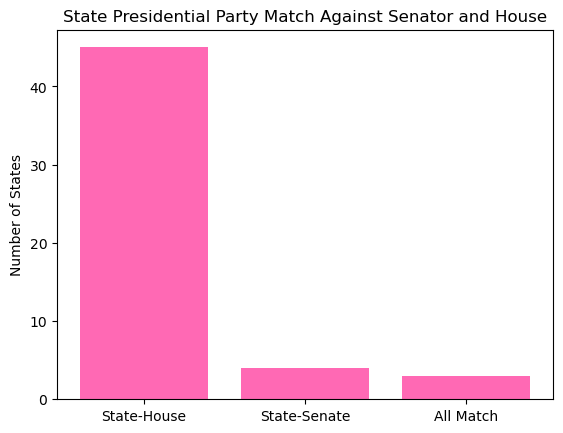

In [22]:
categories = ["State-House", "State-Senate", "All Match"]
num_students = [state_match_house, state_match_senator, state_match_both]

plt.bar(x = categories, height = num_students, color = "hotpink")
plt.ylabel("Number of States")
plt.title("State Presidential Party Match Against Senator and House")
plt.show()

In [ ]:
table_2 = pd.crosstab(index = carfeatures['cylinders'],columns = carfeatures['mpg'])
display(table_2)